In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as prepoc
from sklearn.preprocessing import OneHotEncoder, StandardScaler
%matplotlib inline

### Loading data

In [2]:
data_dir = "../data/train.csv"
df = pd.read_csv(data_dir)

### Features that describe the exterior of the house

- RoofStyle: Type of roof
- RoofMatl: Type of roof material
- Exterior1st: Type of exterior covering on house
- Exterior2nd: Type of exterior covering on house(if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Evaluates the quality of the material on the exterior
- ExterCond: Evaluates the present condition of the material on the exterior
- Foundation: Type of foundation
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet

### Exploring the column values of RoofStyle

In [3]:
df.RoofStyle.unique()

array(['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat', 'Shed'], dtype=object)

In [4]:
df.RoofStyle.value_counts()

RoofStyle
Gable      1141
Hip         286
Flat         13
Gambrel      11
Mansard       7
Shed          2
Name: count, dtype: int64

#### Checking how prices differentiate depending on the type of roof involved in the sale

In [5]:
rf_stl_df = pd.concat([df[["RoofStyle"]], df[["SalePrice"]]], axis=1)

In [6]:
avg_price_per_rf_stl = rf_stl_df.groupby("RoofStyle")["SalePrice"].mean().round().reset_index()
avg_price_per_rf_stl = avg_price_per_rf_stl.sort_values("SalePrice")
avg_price_per_rf_stl = avg_price_per_rf_stl.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_rf_stl

,RoofStyle,AvgSalePrice
2,Gambrel,148909.0
1,Gable,171484.0
4,Mansard,180568.0
0,Flat,194690.0
3,Hip,218877.0
5,Shed,225000.0


### Exploring the column values of RoofMatl

In [7]:
df.RoofMatl.unique()

array(['CompShg', 'WdShngl', 'Metal', 'WdShake', 'Membran', 'Tar&Grv',
       'Roll', 'ClyTile'], dtype=object)

In [8]:
df.RoofMatl.value_counts()

RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

#### Checking how prices differentiate depending on the type of material of the roof

In [9]:
rf_mtl_df = pd.concat([df[["RoofMatl"]], df[["SalePrice"]]], axis=1)

In [10]:
avg_price_per_rf_mtl = rf_mtl_df.groupby("RoofMatl")["SalePrice"].mean().round().reset_index()
avg_price_per_rf_mtl = avg_price_per_rf_mtl.sort_values("SalePrice")
avg_price_per_rf_mtl = avg_price_per_rf_mtl.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_rf_mtl

,RoofMatl,AvgSalePrice
4,Roll,137000.0
0,ClyTile,160000.0
1,CompShg,179804.0
3,Metal,180000.0
5,Tar&Grv,185406.0
6,WdShake,241400.0
2,Membran,241500.0
7,WdShngl,390250.0


### Exploring the column values of Exterior1st

In [11]:
df.Exterior1st.unique()

array(['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing',
       'CemntBd', 'Plywood', 'AsbShng', 'Stucco', 'BrkComm', 'AsphShn',
       'Stone', 'ImStucc', 'CBlock'], dtype=object)

In [12]:
df.Exterior1st.value_counts()

Exterior1st
VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
BrkComm      2
Stone        2
AsphShn      1
ImStucc      1
CBlock       1
Name: count, dtype: int64

#### Checking how prices differentiate depending on the type of Exterior convering on house

In [13]:
extr_1st_df = pd.concat([df[["Exterior1st"]], df[["SalePrice"]]], axis=1)

In [14]:
avg_price_per_extr_1st = extr_1st_df.groupby("Exterior1st")["SalePrice"].mean().round().reset_index()
avg_price_per_extr_1st = avg_price_per_extr_1st.sort_values("SalePrice")
avg_price_per_extr_1st = avg_price_per_extr_1st.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_extr_1st

,Exterior1st,AvgSalePrice
2,BrkComm,71000.0
1,AsphShn,100000.0
4,CBlock,105000.0
0,AsbShng,107386.0
8,MetalSd,149422.0
13,Wd Sdng,149842.0
14,WdShing,150655.0
11,Stucco,162990.0
6,HdBoard,163077.0
9,Plywood,175942.0


### Exploring the column values of Exterior2nd

In [15]:
df.Exterior2nd.unique()

array(['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng',
       'CmentBd', 'BrkFace', 'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc',
       'AsphShn', 'Stone', 'Other', 'CBlock'], dtype=object)

In [16]:
df.Exterior2nd.value_counts()

Exterior2nd
VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
Other        1
CBlock       1
Name: count, dtype: int64

#### Checking how prices differentiate depending on the type of 2nd Exterior convering on house (if present)

In [17]:
extr_2nd_df = pd.concat([df[["Exterior2nd"]], df[["SalePrice"]]], axis=1)

In [18]:
avg_price_per_extr_2nd = extr_2nd_df.groupby("Exterior2nd")["SalePrice"].mean().round().reset_index()
avg_price_per_extr_2nd = avg_price_per_extr_2nd.sort_values("SalePrice")
avg_price_per_extr_2nd = avg_price_per_extr_2nd.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_extr_2nd

,Exterior2nd,AvgSalePrice
4,CBlock,105000.0
0,AsbShng,114061.0
2,Brk Cmn,126714.0
1,AsphShn,138000.0
14,Wd Sdng,148386.0
8,MetalSd,149803.0
12,Stucco,155905.0
11,Stone,158225.0
15,Wd Shng,161329.0
6,HdBoard,167662.0


### Exploring the column values of MasVnrType

In [19]:
df.MasVnrType.unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [20]:
df.MasVnrType.value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [21]:
n_nan = df.MasVnrType.isna().sum()
print(f"Number of nulls: {n_nan}")

Number of nulls: 872


#### Checking how prices differentiate depending on the Masonry veneer type

In [22]:
mas_vnr_tp_df = pd.concat([df[["MasVnrType"]], df[["SalePrice"]]], axis=1)

In [23]:
avg_price_per_mas_vnr_tp = mas_vnr_tp_df.groupby("MasVnrType")["SalePrice"].mean().round().reset_index()
avg_price_per_mas_vnr_tp = avg_price_per_mas_vnr_tp.sort_values("SalePrice")
avg_price_per_mas_vnr_tp = avg_price_per_mas_vnr_tp.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_mas_vnr_tp

,MasVnrType,AvgSalePrice
0,BrkCmn,146318.0
1,BrkFace,204692.0
2,Stone,265584.0


### Exploring the column values of ExterQual

In [24]:
df.ExterQual.unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [25]:
df.ExterQual.value_counts()

ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

#### Checking how prices differentiate depending on the quality of the material on the exterior

In [26]:
extr_ql_df = pd.concat([df[["ExterQual"]], df[["SalePrice"]]], axis=1)

In [27]:
avg_price_per_extr_ql = extr_ql_df.groupby("ExterQual")["SalePrice"].mean().round().reset_index()
avg_price_per_extr_ql = avg_price_per_extr_ql.sort_values("SalePrice")
avg_price_per_extr_ql = avg_price_per_extr_ql.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_extr_ql

,ExterQual,AvgSalePrice
1,Fa,87985.0
3,TA,144341.0
2,Gd,231634.0
0,Ex,367361.0


### Exploring the column values of ExterCond

In [28]:
df.ExterCond.unique()

array(['TA', 'Gd', 'Fa', 'Po', 'Ex'], dtype=object)

In [29]:
df.ExterCond.value_counts()

ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

#### Checking how prices differentiate depending on the condition of the material on the exterior

In [30]:
extr_cond_df = pd.concat([df[["ExterCond"]], df[["SalePrice"]]], axis=1)

In [31]:
avg_price_per_extr_cond = extr_cond_df.groupby("ExterCond")["SalePrice"].mean().round().reset_index()
avg_price_per_extr_cond = avg_price_per_extr_cond.sort_values("SalePrice")
avg_price_per_extr_cond = avg_price_per_extr_cond.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_extr_cond

,ExterCond,AvgSalePrice
3,Po,76500.0
1,Fa,102595.0
2,Gd,168898.0
4,TA,184035.0
0,Ex,201333.0


### Exploring the column values of Foundation

In [32]:
df.Foundation.unique()

array(['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab', 'Stone'], dtype=object)

In [33]:
df.Foundation.value_counts()

Foundation
PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: count, dtype: int64

#### Checking how prices differentiate depending on the Type of foundation

In [37]:
fnd_tp_df = pd.concat([df[["Foundation"]], df[["SalePrice"]]], axis=1)

In [38]:
avg_price_per_fnd_tp = fnd_tp_df.groupby("Foundation")["SalePrice"].mean().round().reset_index()
avg_price_per_fnd_tp = avg_price_per_fnd_tp.sort_values("SalePrice")
avg_price_per_fnd_tp = avg_price_per_fnd_tp.rename(columns={"SalePrice": "AvgSalePrice"})
avg_price_per_fnd_tp

,Foundation,AvgSalePrice
3,Slab,107366.0
0,BrkTil,132291.0
1,CBlock,149806.0
4,Stone,165959.0
5,Wood,185667.0
2,PConc,225230.0


### Exploring the column values of MasVnrArea

In [39]:
df.MasVnrArea.describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

In [40]:
n_nan = df.MasVnrArea.isna().sum().item()
print(f"Number of nans in MasVnrArea: {n_nan}")

Number of nans in MasVnrArea: 8


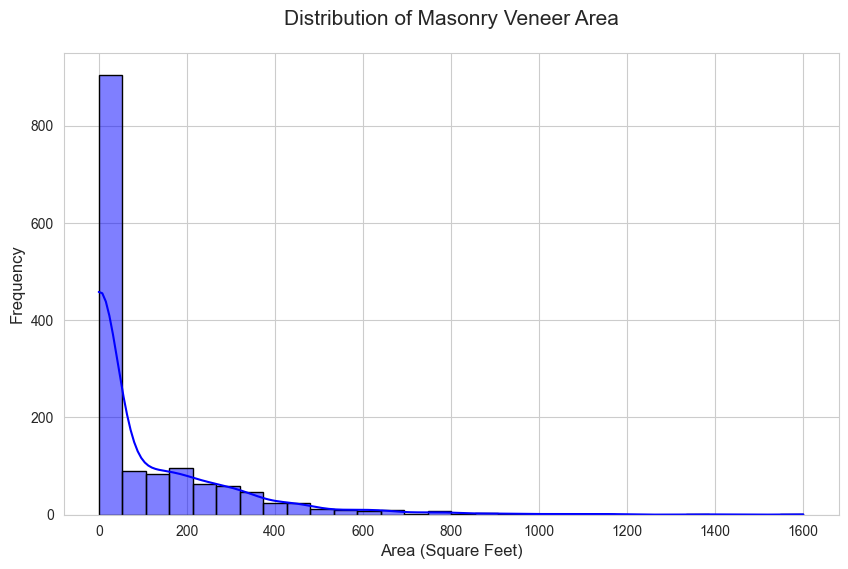

In [81]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['MasVnrArea'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Masonry Veneer Area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of WoodDeckSF

In [42]:
df.WoodDeckSF.describe()

count    1460.000000
mean       94.244521
std       125.338794
min         0.000000
25%         0.000000
50%         0.000000
75%       168.000000
max       857.000000
Name: WoodDeckSF, dtype: float64

In [43]:
n_nan = df.WoodDeckSF.isna().sum().item()
print(f"Number of nans in WoodDeckSF: {n_nan}")

Number of nans in WoodDeckSF: 0


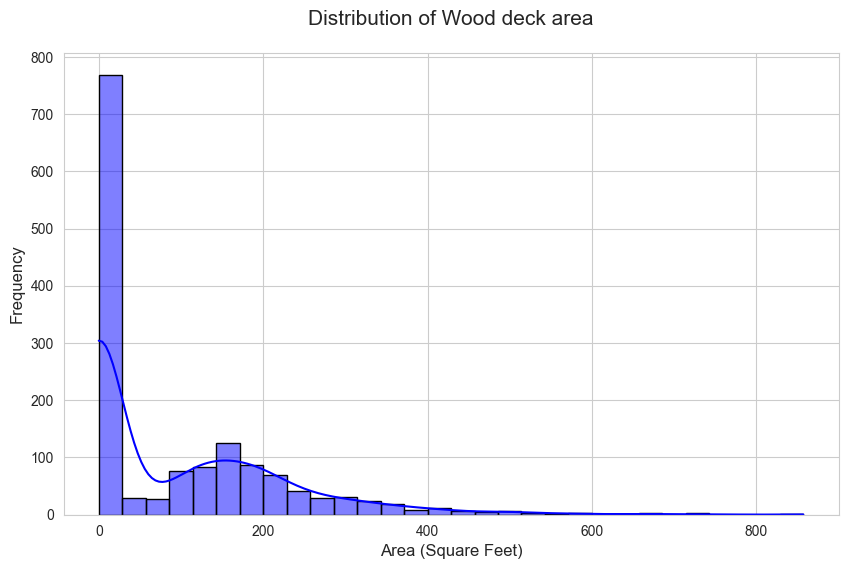

In [82]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['WoodDeckSF'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Wood deck area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of OpenPorchSF

In [45]:
df.OpenPorchSF.describe()

count    1460.000000
mean       46.660274
std        66.256028
min         0.000000
25%         0.000000
50%        25.000000
75%        68.000000
max       547.000000
Name: OpenPorchSF, dtype: float64

In [46]:
n_nan = df.OpenPorchSF.isna().sum().item()
print(f"Number of nans in OpenPorchSF: {n_nan}")

Number of nans in OpenPorchSF: 0


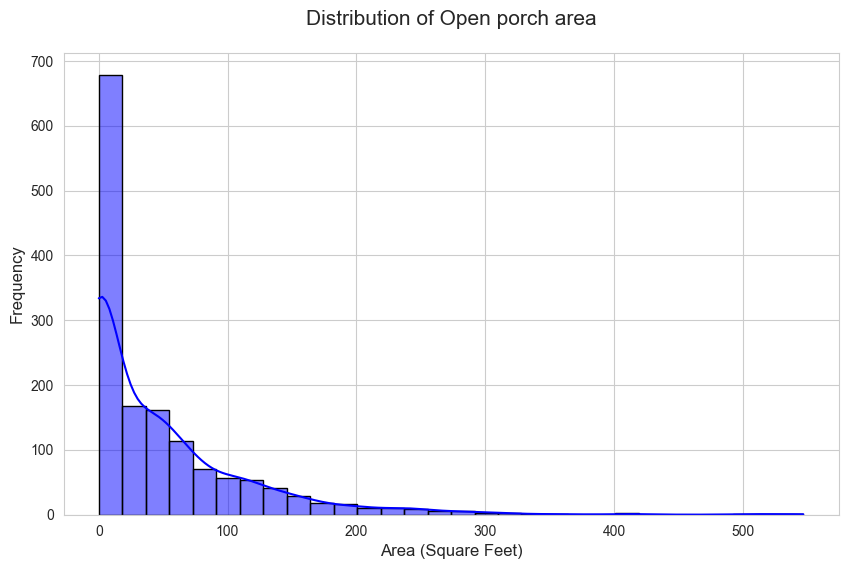

In [83]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['OpenPorchSF'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Open porch area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of EnclosedPorch

In [48]:
df.EnclosedPorch.describe()

count    1460.000000
mean       21.954110
std        61.119149
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       552.000000
Name: EnclosedPorch, dtype: float64

In [49]:
n_nan = df.EnclosedPorch.isna().sum().item()
print(f"Number of nans in EnclosedPorch: {n_nan}")

Number of nans in EnclosedPorch: 0


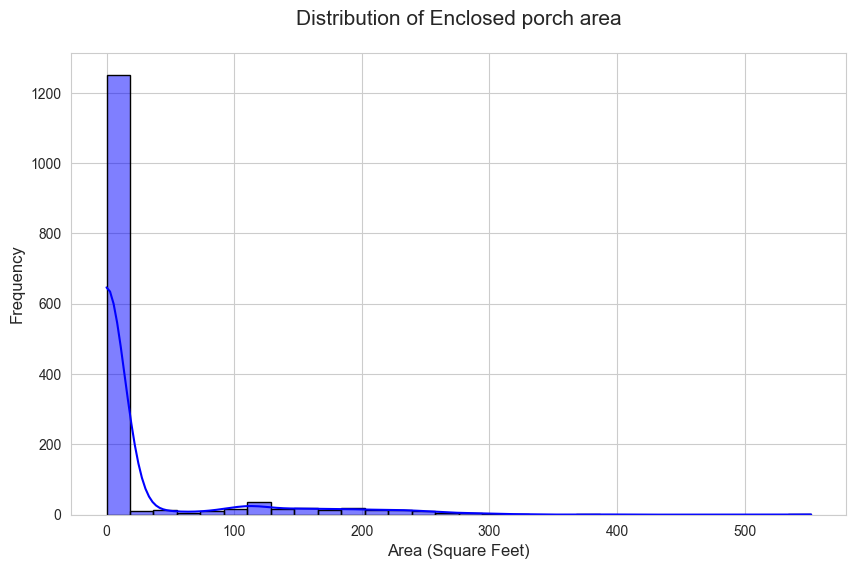

In [84]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['EnclosedPorch'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Enclosed porch area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of 3SsnPorch

In [52]:
df["3SsnPorch"].describe()

count    1460.000000
mean        3.409589
std        29.317331
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       508.000000
Name: 3SsnPorch, dtype: float64

In [53]:
n_nan = df["3SsnPorch"].isna().sum().item()
print(f"Number of nans in 3SsnPorch: {n_nan}")

Number of nans in 3SsnPorch: 0


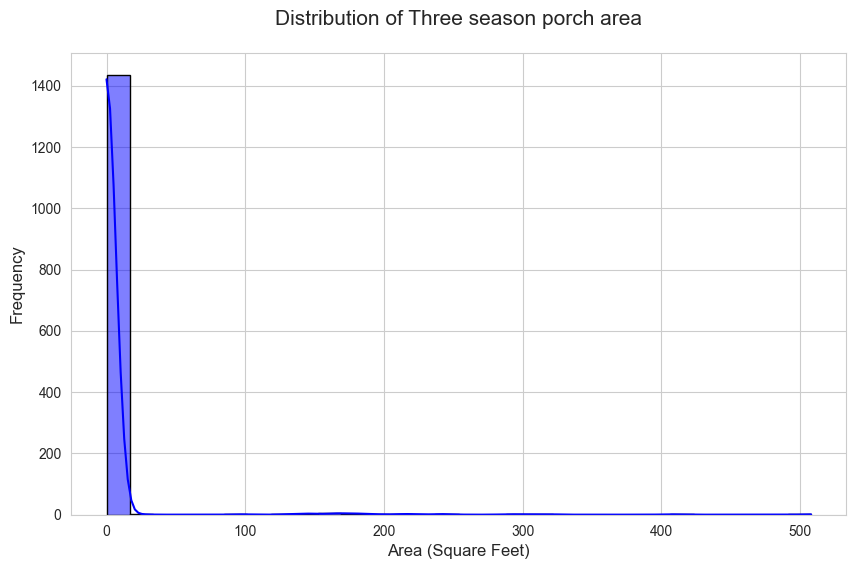

In [85]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['3SsnPorch'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Three season porch area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

### Exploring the column values of ScreenPorch

In [55]:
df.ScreenPorch.describe()

count    1460.000000
mean       15.060959
std        55.757415
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       480.000000
Name: ScreenPorch, dtype: float64

In [56]:
n_nan = df.ScreenPorch.isna().sum().item()
print(f"Number of nans in ScreenPorch: {n_nan}")

Number of nans in ScreenPorch: 0


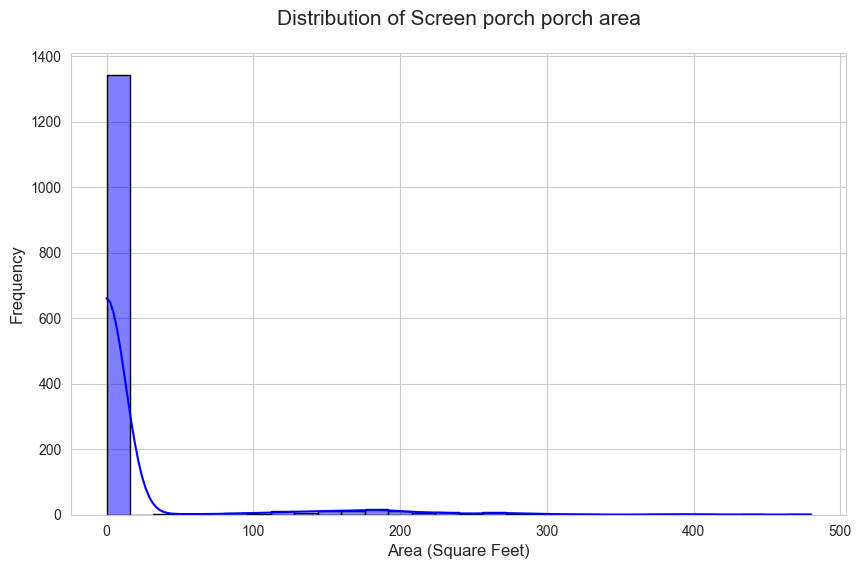

In [86]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['ScreenPorch'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of Screen porch porch area", fontsize=15, pad=20)
plt.xlabel("Area (Square Feet)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()